# Gráficas auxiliares — Error de estimación de $\theta$

Bajo $H_0$ las distribuciones son simétricas con centro $\theta$ conocido (Uniforme(1,3): $\theta=2$; Cauchy(loc=2): $\theta=2$). Este notebook estudia el desempeño de los tres estimadores del centro — `argmin`, `median`, `trimmed` — comparando su error $\hat\theta - \theta$ por distribución, tamaño de muestra y, en el caso de $S_n$, por función de peso y exponente $q$.

**Métricas:**
- **Sesgo**: $\mathrm{bias} = \bar{\hat\theta} - \theta$
- **MAD** (mediana del valor absoluto del error): robusta a colas pesadas
- **RMSE**: $\sqrt{\overline{(\hat\theta - \theta)^2}}$ — sensible a outliers (especialmente bajo Cauchy)

Las figuras se guardan en `results/figures/aux_*.png`.

In [13]:
import sys, os, re
from pathlib import Path

ROOT = Path.cwd().parent if (Path.cwd().name == 'notebooks') else Path.cwd()
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

FIG_DIR = ROOT / 'results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

ESTIMATOR_ORDER = ['argmin', 'median', 'trimmed']
ESTIMATOR_COLOR = {'argmin': 'C0', 'median': 'C1', 'trimmed': 'C2'}

print(f'Working dir: {Path.cwd()}')

Working dir: C:\Users\tejon\PycharmProjects\Proyecto2EstadisticaNP


## Cargar datos crudos

Cambiar `use_quick = True` para usar los datasets reducidos.

In [14]:
use_quick = False
suffix = '_quick' if use_quick else ''

tn_raw_path = ROOT / 'results' / 'data' / f'tn_simulation_raw{suffix}.csv'
sn_raw_path = ROOT / 'results' / 'data' / f'sn_simulation_raw{suffix}.csv'

tn_df = pd.read_csv(tn_raw_path) if tn_raw_path.exists() else None
sn_df = pd.read_csv(sn_raw_path) if sn_raw_path.exists() else None

if tn_df is None:
    print(f'(!) No se encontró {tn_raw_path.name}')
else:
    print(f'Tn: {len(tn_df):,} filas — dists: {sorted(tn_df.dist.unique())}')
if sn_df is None:
    print(f'(!) No se encontró {sn_raw_path.name}')
else:
    print(f'Sn: {len(sn_df):,} filas — q={sorted(sn_df.q.unique())}, weights={sorted(sn_df.weight.unique())}')

Tn: 18,000 filas — dists: ['Cauchy(loc=2.0,scale=1.0)', 'Gamma(k=2.0,s=1.0)', 'Pareto(a=3.0,s=1.0)', 'Uniforme(1.0,3.0)', 'Weibull(k=1.5,s=1.0)']
Sn: 72,000 filas — q=[np.int64(1), np.int64(2)], weights=['gauss_0.5', 'gauss_1.0', 'laplace_1.0']


## $\theta$ verdadero por distribución

Se extrae directamente del nombre del escenario (`Uniforme(a,b)` → $(a+b)/2$, `Cauchy(loc=…,scale=…)` → `loc`, `Normal(loc=…,scale=…)` → `loc`). Bajo $H_a$ no existe $\theta$ verdadero, así que esas filas quedan fuera del análisis.

In [15]:
def theta_true_from_name(name: str) -> float | None:
    """Recupera theta verdadero a partir del nombre del DistSpec."""
    m = re.match(r'Uniforme\(([-+0-9.eE]+),\s*([-+0-9.eE]+)\)', name)
    if m:
        return (float(m.group(1)) + float(m.group(2))) / 2.0
    m = re.match(r'Cauchy\(loc=([-+0-9.eE]+),.*\)', name)
    if m:
        return float(m.group(1))
    m = re.match(r'Normal\(loc=([-+0-9.eE]+),.*\)', name)
    if m:
        return float(m.group(1))
    return None

def attach_error(df: pd.DataFrame) -> pd.DataFrame:
    """Filtra a H0, agrega columna theta_true y error = theta_hat - theta_true."""
    out = df[df['under_h0'] == True].copy()
    out['theta_true'] = out['dist'].map(theta_true_from_name)
    out = out.dropna(subset=['theta_true'])
    out['error'] = out['theta_hat'] - out['theta_true']
    out['abs_error'] = out['error'].abs()
    return out

tn_h0 = attach_error(tn_df) if tn_df is not None else None
sn_h0 = attach_error(sn_df) if sn_df is not None else None

if tn_h0 is not None:
    print('Tn bajo H0:')
    display(tn_h0.groupby(['dist'])['theta_true'].first().to_frame())
if sn_h0 is not None:
    print('Sn bajo H0:')
    display(sn_h0.groupby(['dist'])['theta_true'].first().to_frame())

Tn bajo H0:


,theta_true
dist,
"Cauchy(loc=2.0,scale=1.0)",2.0
"Uniforme(1.0,3.0)",2.0


Sn bajo H0:


,theta_true
dist,
"Cauchy(loc=2.0,scale=1.0)",2.0
"Uniforme(1.0,3.0)",2.0


## Test 1 — Resumen numérico

Sesgo, RMSE y MAD por (distribución, $n$, estimador).

In [16]:
def error_summary(df_h0: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    g = df_h0.groupby(group_cols)
    out = pd.DataFrame({
        'n_rep'  : g['error'].size(),
        'bias'   : g['error'].mean(),
        'std'    : g['error'].std(),
        'rmse'   : np.sqrt(g['error'].apply(lambda s: (s**2).mean())),
        'mad'    : g['abs_error'].median(),
    })
    return out.reset_index()

if tn_h0 is not None:
    tn_summary = error_summary(tn_h0, ['dist', 'n', 'estimator'])
    print('RMSE por celda (Test 1):')
    display(tn_summary.pivot_table(index=['dist','estimator'], columns='n', values='rmse').round(4))
    print('Sesgo:')
    display(tn_summary.pivot_table(index=['dist','estimator'], columns='n', values='bias').round(4))
    print('MAD (mediana del |error|):')
    display(tn_summary.pivot_table(index=['dist','estimator'], columns='n', values='mad').round(4))

RMSE por celda (Test 1):


n                                          20        40        80         160
dist                      estimator                                          
Cauchy(loc=2.0,scale=1.0) argmin     4587.3420  381.9729  901.1520  2078.1347
                          median        0.3607    0.2470    0.1798     0.1236
                          trimmed       0.6297    0.3938    0.2685     0.1879
Uniforme(1.0,3.0)         argmin        0.1477    0.0992    0.0683     0.0445
                          median        0.2038    0.1453    0.1048     0.0826
                          trimmed       0.1542    0.1048    0.0769     0.0534

Sesgo:


n                                         20       40       80        160
dist                      estimator                                      
Cauchy(loc=2.0,scale=1.0) argmin    -268.3253 -22.4048 -64.5206 -115.7256
                          median      -0.0179   0.0223   0.0020    0.0012
                          trimmed     -0.0760   0.0112   0.0218    0.0078
Uniforme(1.0,3.0)         argmin      -0.0001  -0.0034  -0.0008   -0.0033
                          median      -0.0062  -0.0041   0.0025   -0.0030
                          trimmed      0.0152   0.0076   0.0042    0.0012

MAD (mediana del |error|):


n                                       20      40      80      160
dist                      estimator                                
Cauchy(loc=2.0,scale=1.0) argmin     0.2582  0.1687  0.1273  0.0877
                          median     0.2242  0.1541  0.1253  0.0830
                          trimmed    0.3936  0.2359  0.1686  0.1137
Uniforme(1.0,3.0)         argmin     0.0955  0.0657  0.0439  0.0332
                          median     0.1460  0.0870  0.0701  0.0608
                          trimmed    0.1133  0.0784  0.0503  0.0375

## Test 1 — Boxplots del error

Distribución del error $\hat\theta - \theta$ por estimador y $n$. Para Cauchy se recortan los whiskers a percentiles [1, 99] para que se aprecien las cajas (las colas pesadas dominarían la escala).

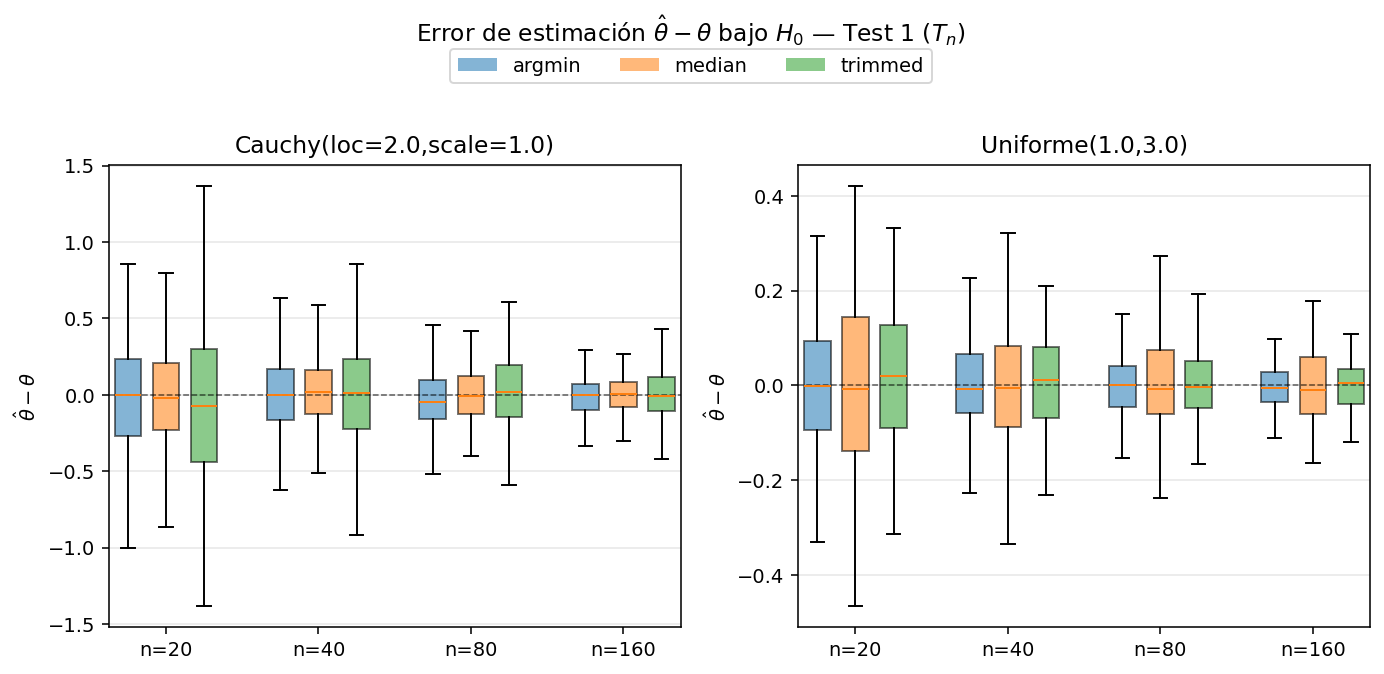

In [17]:
def boxplot_error_by_estimator(df_h0: pd.DataFrame, title_suffix: str, out_path: Path, clip_percentile: tuple[float,float] | None = None):
    dists = sorted(df_h0['dist'].unique())
    ns = sorted(df_h0['n'].unique())
    fig, axes = plt.subplots(1, len(dists), figsize=(5*len(dists), 4.5), sharey=False)
    if len(dists) == 1:
        axes = [axes]
    for ax, dist in zip(axes, dists):
        sub = df_h0[df_h0['dist'] == dist]
        positions = []
        labels = []
        data = []
        colors = []
        for i, n in enumerate(ns):
            for j, est in enumerate(ESTIMATOR_ORDER):
                vals = sub[(sub['n']==n) & (sub['estimator']==est)]['error'].values
                if clip_percentile is not None and vals.size > 0:
                    lo_p, hi_p = np.nanpercentile(vals, clip_percentile)
                    vals = vals[(vals >= lo_p) & (vals <= hi_p)]
                positions.append(i*4 + j)
                data.append(vals)
                labels.append(est if i == 0 else '')
                colors.append(ESTIMATOR_COLOR[est])
        bp = ax.boxplot(data, positions=positions, widths=0.7, patch_artist=True, showfliers=False)
        for patch, c in zip(bp['boxes'], colors):
            patch.set_facecolor(c)
            patch.set_alpha(0.55)
        ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.6)
        ax.set_xticks([i*4 + 1 for i in range(len(ns))])
        ax.set_xticklabels([f'n={n}' for n in ns])
        ax.set_title(dist)
        ax.set_ylabel(r'$\hat\theta - \theta$')
        ax.grid(True, axis='y', alpha=0.3)
    handles = [plt.Rectangle((0,0),1,1, fc=ESTIMATOR_COLOR[e], alpha=0.55, label=e) for e in ESTIMATOR_ORDER]
    fig.legend(handles=handles, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(f'Error de estimación $\\hat\\theta - \\theta$ bajo $H_0$ — {title_suffix}', y=1.06)
    fig.tight_layout()
    fig.savefig(out_path, dpi=140, bbox_inches='tight')
    plt.close(fig)
    return out_path

if tn_h0 is not None:
    # Sin recorte: muestra la diferencia real de robustez (Cauchy estallará)
    p = boxplot_error_by_estimator(tn_h0, 'Test 1 ($T_n$)', FIG_DIR / 'aux_tn_error_boxplot.png',
                                    clip_percentile=(1, 99))
    display(Image(filename=str(p)))

## Test 1 — RMSE y MAD vs $n$

Para distribuciones con varianza finita (Uniforme), el RMSE debe decaer como $1/\sqrt n$. Para Cauchy la varianza de la media muestral es infinita, pero **la mediana sí tiene varianza finita** — esperamos verla colapsar mientras que la trimmed mean se queda alta y errática.

Se muestran dos métricas: RMSE (sensible) y MAD (robusta).

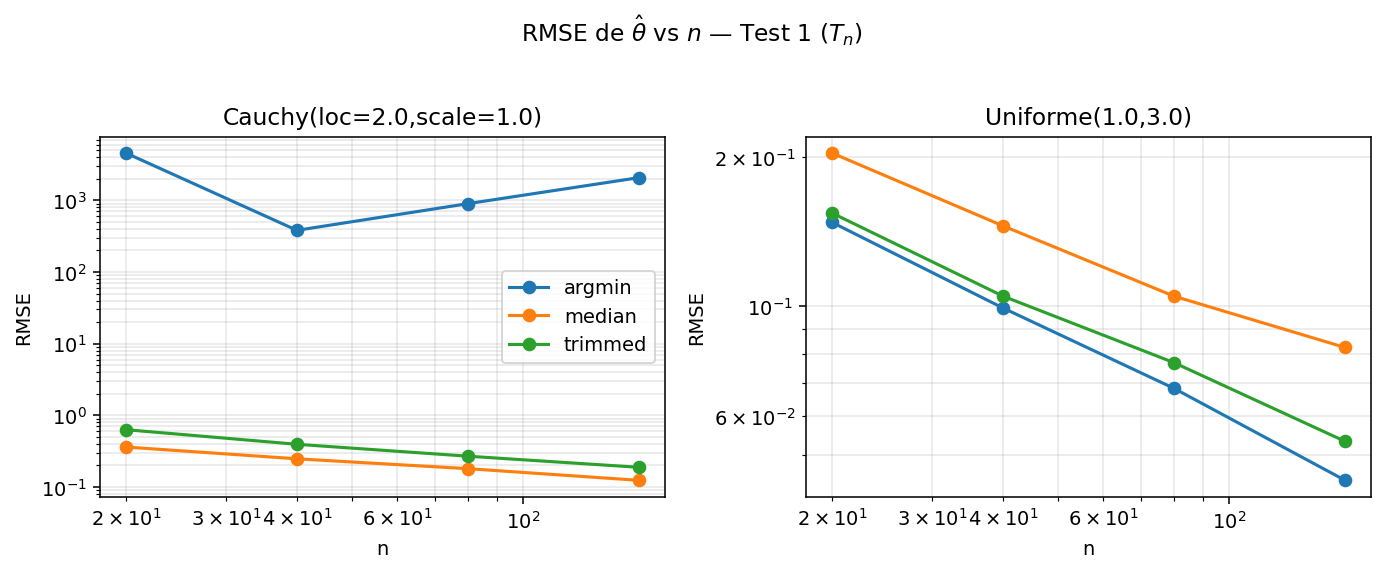

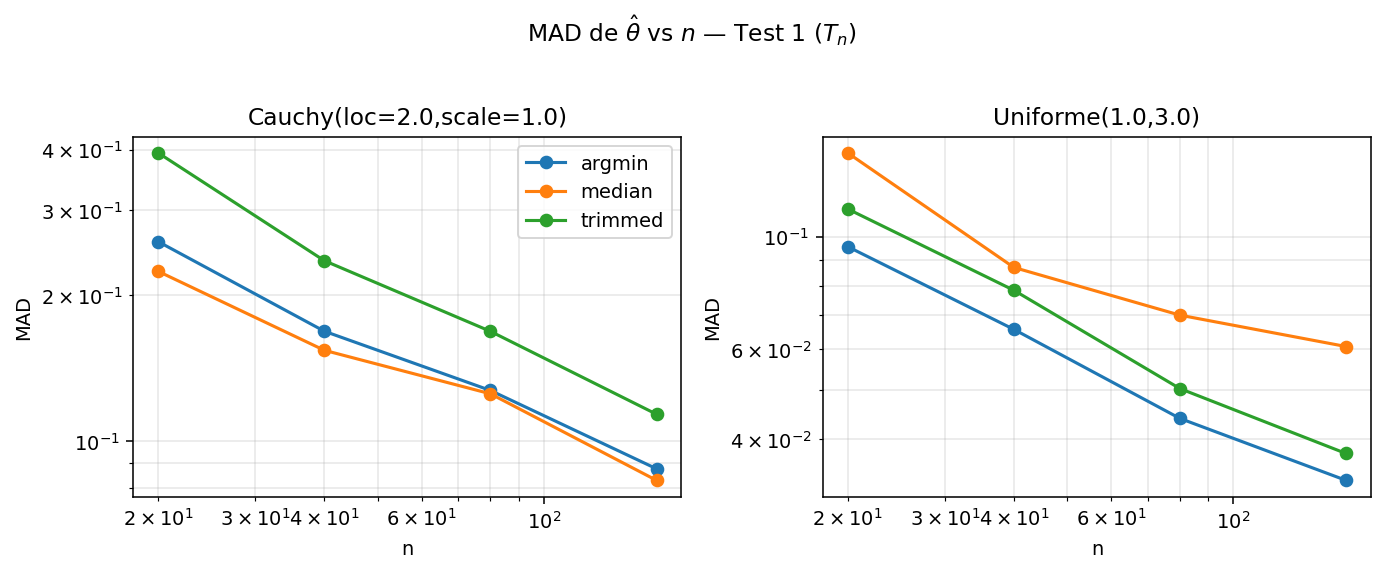

In [18]:
def plot_metric_vs_n(summary: pd.DataFrame, metric: str, title_suffix: str, out_path: Path):
    dists = sorted(summary['dist'].unique())
    fig, axes = plt.subplots(1, len(dists), figsize=(5*len(dists), 4), sharey=False)
    if len(dists) == 1:
        axes = [axes]
    for ax, dist in zip(axes, dists):
        sub = summary[summary['dist'] == dist]
        for est in ESTIMATOR_ORDER:
            s = sub[sub['estimator']==est].sort_values('n')
            ax.plot(s['n'], s[metric], 'o-', color=ESTIMATOR_COLOR[est], label=est, lw=1.6, ms=6)
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlabel('n'); ax.set_ylabel(metric.upper())
        ax.set_title(dist)
        ax.grid(True, which='both', alpha=0.3)
    axes[0].legend()
    fig.suptitle(f'{metric.upper()} de $\\hat\\theta$ vs $n$ — {title_suffix}', y=1.02)
    fig.tight_layout()
    fig.savefig(out_path, dpi=140, bbox_inches='tight')
    plt.close(fig)
    return out_path

if tn_h0 is not None:
    p = plot_metric_vs_n(tn_summary, 'rmse', 'Test 1 ($T_n$)', FIG_DIR / 'aux_tn_rmse_vs_n.png')
    display(Image(filename=str(p)))
    p = plot_metric_vs_n(tn_summary, 'mad', 'Test 1 ($T_n$)', FIG_DIR / 'aux_tn_mad_vs_n.png')
    display(Image(filename=str(p)))

## Test 1 — Sesgo vs $n$

Los tres estimadores son consistentes para el centro de simetría, así que el sesgo debe converger a 0. Como las distribuciones son simétricas, el sesgo poblacional es 0 por construcción; lo que vemos es el error muestral en estimar la media.

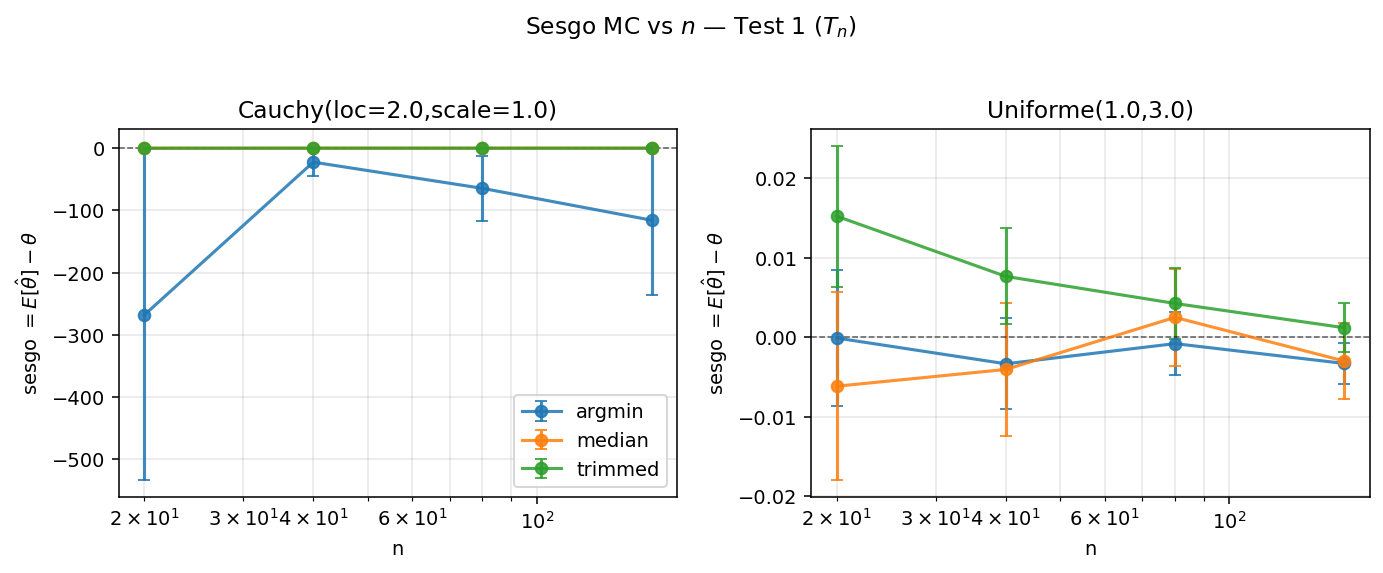

In [19]:
def plot_bias_vs_n(summary: pd.DataFrame, title_suffix: str, out_path: Path):
    dists = sorted(summary['dist'].unique())
    fig, axes = plt.subplots(1, len(dists), figsize=(5*len(dists), 4), sharey=False)
    if len(dists) == 1:
        axes = [axes]
    for ax, dist in zip(axes, dists):
        sub = summary[summary['dist'] == dist]
        for est in ESTIMATOR_ORDER:
            s = sub[sub['estimator']==est].sort_values('n')
            # Banda ±1 SE del sesgo (s.e. de la media MC)
            se = s['std'] / np.sqrt(s['n_rep'])
            ax.errorbar(s['n'], s['bias'], yerr=se, fmt='o-',
                        color=ESTIMATOR_COLOR[est], label=est, lw=1.6, ms=6,
                        capsize=3, alpha=0.85)
        ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.6)
        ax.set_xscale('log')
        ax.set_xlabel('n'); ax.set_ylabel(r'sesgo $= E[\hat\theta] - \theta$')
        ax.set_title(dist)
        ax.grid(True, which='both', alpha=0.3)
    axes[0].legend()
    fig.suptitle(f'Sesgo MC vs $n$ — {title_suffix}', y=1.02)
    fig.tight_layout()
    fig.savefig(out_path, dpi=140, bbox_inches='tight')
    plt.close(fig)
    return out_path

if tn_h0 is not None:
    p = plot_bias_vs_n(tn_summary, 'Test 1 ($T_n$)', FIG_DIR / 'aux_tn_bias_vs_n.png')
    display(Image(filename=str(p)))

## Test 2 — Resumen numérico

Para `argmin` el resultado depende de $(q, w)$ — al cambiarlos cambia la función objetivo y por tanto el mínimo. Para `median` y `trimmed` el estimador no depende de esos parámetros, pero como cada réplica usa su propio seed, las filas con distintos $(q,w)$ son réplicas Monte Carlo independientes del mismo estimador y podemos promediarlas.

Reportamos las métricas agrupadas por $(\text{dist}, n, \text{estimator}, q, w)$ — ahí ven el efecto del peso/exponente sobre `argmin`.

In [20]:
if sn_h0 is not None:
    sn_summary = error_summary(sn_h0, ['dist', 'n', 'estimator', 'q', 'weight'])
    # Solo argmin por (q, w) — para median/trimmed promediamos sobre (q, w)
    sn_summary_pooled = error_summary(
        sn_h0[sn_h0['estimator'].isin(['median','trimmed'])], ['dist','n','estimator']
    )
    print('RMSE de argmin por (q, weight):')
    display(
        sn_summary[sn_summary['estimator']=='argmin']
        .pivot_table(index=['dist','q','weight'], columns='n', values='rmse').round(4)
    )
    print('RMSE de median / trimmed (agrupado sobre q, weight):')
    display(
        sn_summary_pooled.pivot_table(index=['dist','estimator'], columns='n', values='rmse').round(4)
    )

RMSE de argmin por (q, weight):


n                                             20         40          80   \
dist                      q weight                                         
Cauchy(loc=2.0,scale=1.0) 1 gauss_0.5    209.7789    77.7315   1697.5183   
                            gauss_1.0    193.9482    66.8417    393.0930   
                            laplace_1.0   81.8060   487.2191  11312.9851   
                          2 gauss_0.5    353.1929   258.1908    421.1908   
                            gauss_1.0    311.9157   628.2018    589.3814   
                            laplace_1.0  816.7843  3275.5694    142.6136   
Uniforme(1.0,3.0)         1 gauss_0.5      0.1258     0.0955      0.0696   
                            gauss_1.0      0.1351     0.1015      0.0659   
                            laplace_1.0    0.1394     0.1083      0.0687   
                          2 gauss_0.5      0.1294     0.0940      0.0643   
                            gauss_1.0      0.1496     0.1010      0.0783   
                            laplace_1.0    0.1787     0.1245      0.0845   

n                                              160  
dist                      q weight                  
Cauchy(loc=2.0,scale=1.0) 1 gauss_0.5    3214.7740  
                            gauss_1.0    5412.8119  
                            laplace_1.0  1243.1884  
                          2 gauss_0.5    1117.7517  
                            gauss_1.0    1267.0380  
                            laplace_1.0   850.5576  
Uniforme(1.0,3.0)         1 gauss_0.5       0.0458  
                            gauss_1.0       0.0492  
                            laplace_1.0     0.0475  
                          2 gauss_0.5       0.0404  
                            gauss_1.0       0.0556  
                            laplace_1.0     0.0568

RMSE de median / trimmed (agrupado sobre q, weight):


n                                       20      40      80      160
dist                      estimator                                
Cauchy(loc=2.0,scale=1.0) median     0.3628  0.2545  0.1793  0.1250
                          trimmed    0.6342  0.3954  0.2626  0.1792
Uniforme(1.0,3.0)         median     0.2045  0.1526  0.1097  0.0780
                          trimmed    0.1562  0.1081  0.0745  0.0533

## Test 2 — RMSE de `argmin` por peso y $q$

Una grilla de paneles: filas = distribución, columnas = (q, weight). En cada panel, las tres curvas son los estimadores. Permite ver si la elección de $(q, w)$ ayuda al `argmin` a acercarse a la mediana / trimmed (que son fijos).

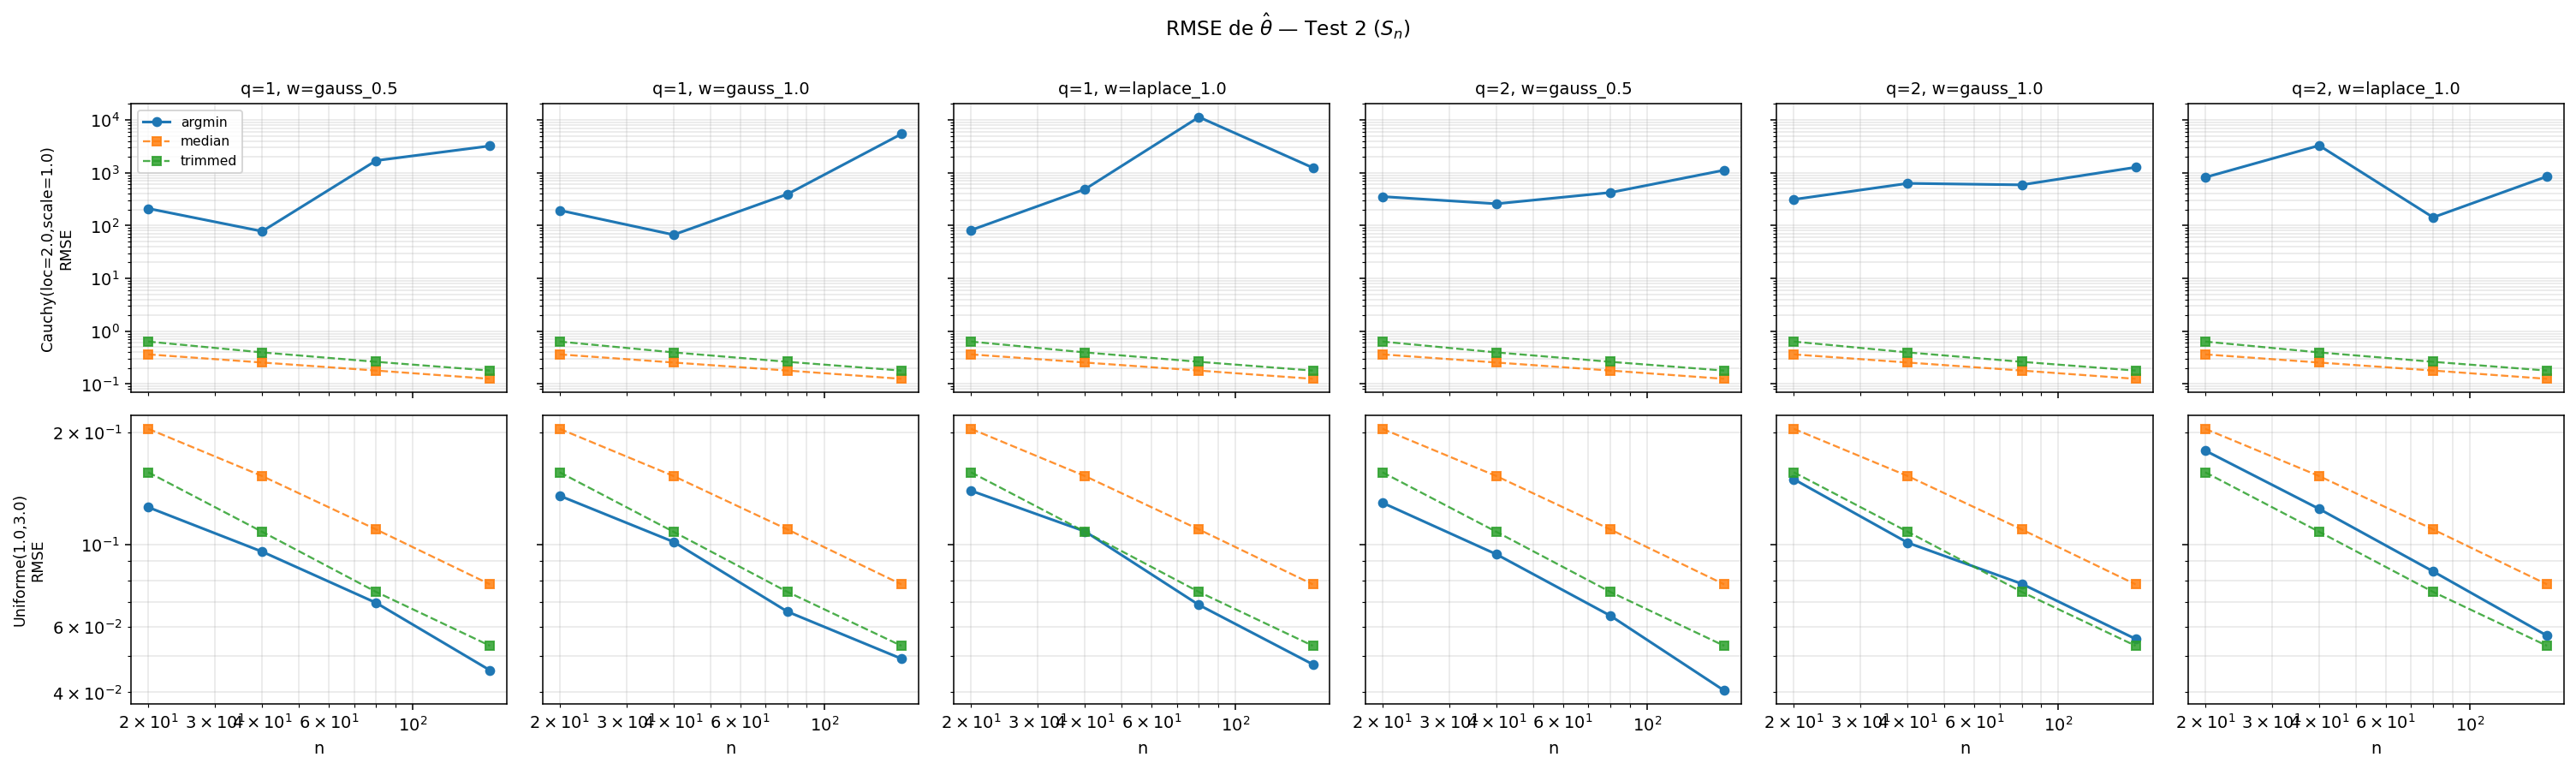

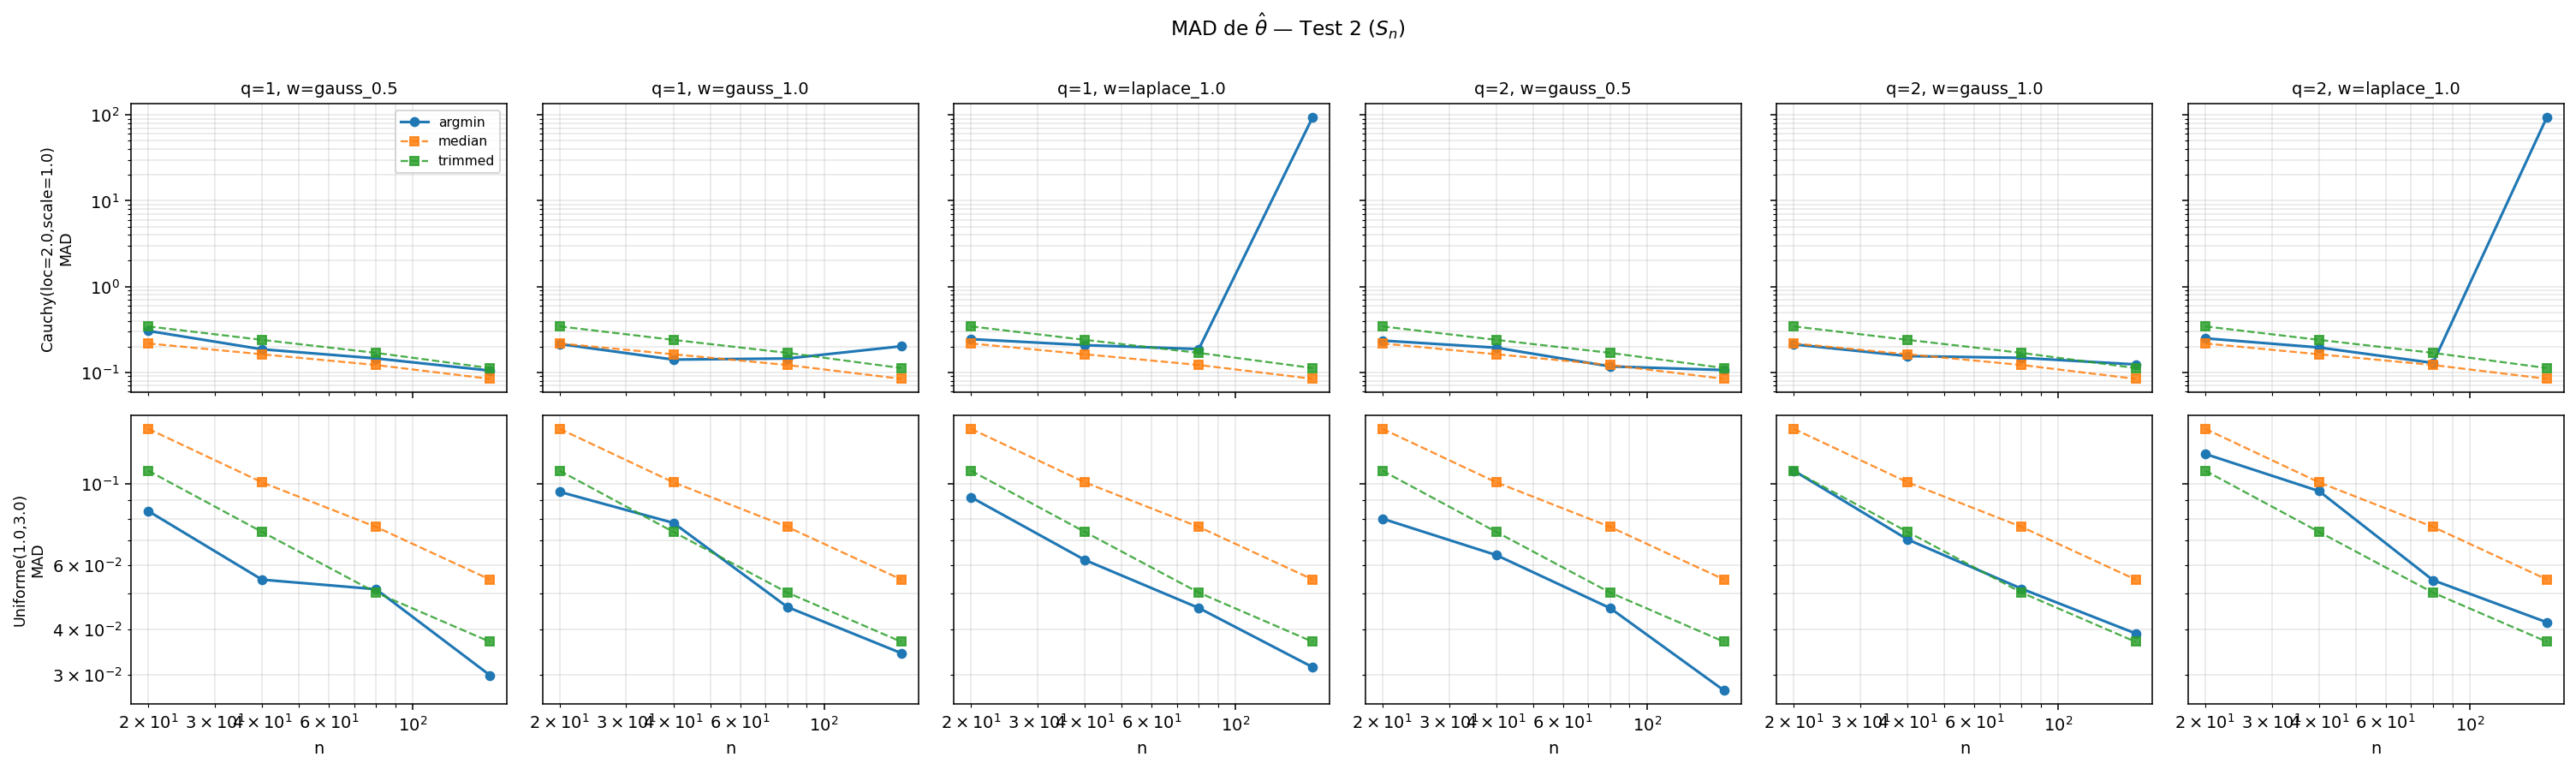

In [21]:
def plot_sn_rmse_grid(sn_h0: pd.DataFrame, sn_summary: pd.DataFrame, sn_summary_pooled: pd.DataFrame,
                      metric: str, out_path: Path):
    dists = sorted(sn_h0['dist'].unique())
    qs = sorted(sn_h0['q'].unique())
    weights = sorted(sn_h0['weight'].unique())
    combos = [(q, w) for q in qs for w in weights]
    nrows, ncols = len(dists), len(combos)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.6*ncols, 3.2*nrows),
                             sharex=True, sharey='row', squeeze=False)
    for i, dist in enumerate(dists):
        for j, (q, w) in enumerate(combos):
            ax = axes[i][j]
            # argmin: depende de (q, w)
            s_arg = sn_summary[(sn_summary['dist']==dist) & (sn_summary['estimator']=='argmin')
                               & (sn_summary['q']==q) & (sn_summary['weight']==w)].sort_values('n')
            ax.plot(s_arg['n'], s_arg[metric], 'o-', color=ESTIMATOR_COLOR['argmin'], label='argmin', lw=1.6, ms=5)
            # median y trimmed: no dependen de (q, w) — usar pooled
            for est in ['median', 'trimmed']:
                s = sn_summary_pooled[(sn_summary_pooled['dist']==dist) & (sn_summary_pooled['estimator']==est)].sort_values('n')
                ax.plot(s['n'], s[metric], 's--', color=ESTIMATOR_COLOR[est], label=est, lw=1.2, ms=5, alpha=0.85)
            ax.set_xscale('log'); ax.set_yscale('log')
            ax.grid(True, which='both', alpha=0.3)
            if i == 0:
                ax.set_title(f'q={q}, w={w}', fontsize=10)
            if j == 0:
                ax.set_ylabel(f'{dist}\n{metric.upper()}', fontsize=9)
            if i == nrows - 1:
                ax.set_xlabel('n')
    axes[0][0].legend(fontsize=8, loc='best')
    fig.suptitle(f'{metric.upper()} de $\\hat\\theta$ — Test 2 ($S_n$)', y=1.00)
    fig.tight_layout()
    fig.savefig(out_path, dpi=140, bbox_inches='tight')
    plt.close(fig)
    return out_path

if sn_h0 is not None:
    p = plot_sn_rmse_grid(sn_h0, sn_summary, sn_summary_pooled, 'rmse', FIG_DIR / 'aux_sn_rmse_grid.png')
    display(Image(filename=str(p)))
    p = plot_sn_rmse_grid(sn_h0, sn_summary, sn_summary_pooled, 'mad', FIG_DIR / 'aux_sn_mad_grid.png')
    display(Image(filename=str(p)))

## Test 2 — `argmin` por configuración para $n$ máximo

Una vista directa: para el mayor $n$ disponible, ¿qué configuración $(q, w)$ produce un `argmin` con menor RMSE / MAD? Se incluyen líneas horizontales de referencia para median y trimmed.

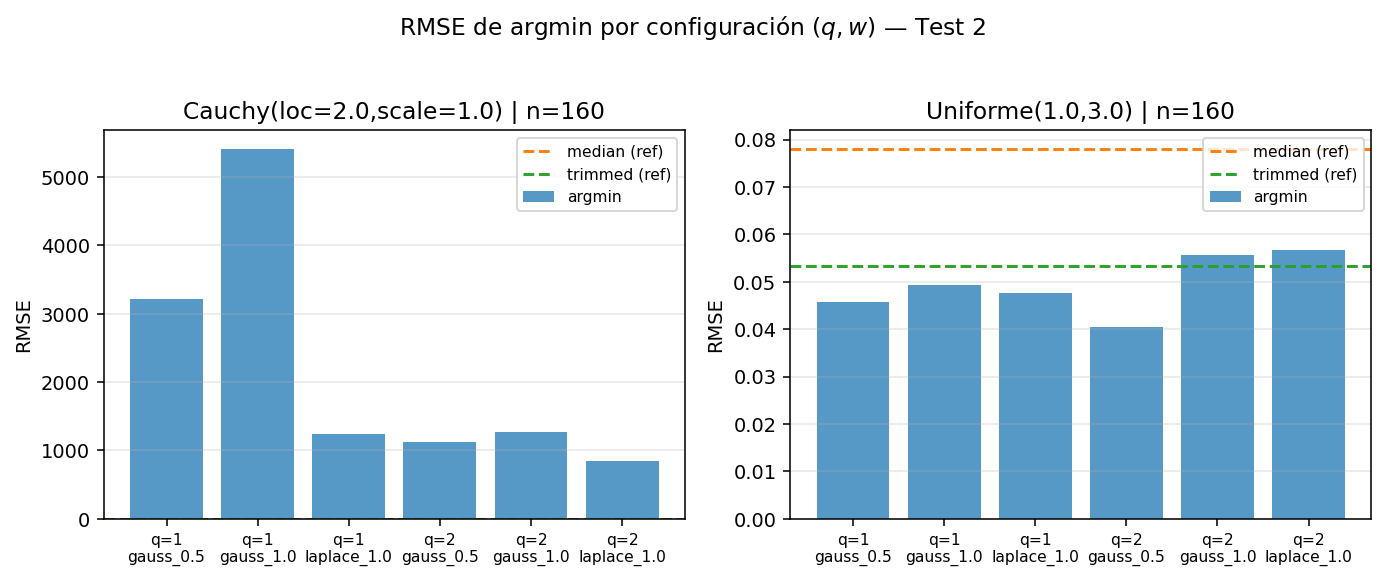

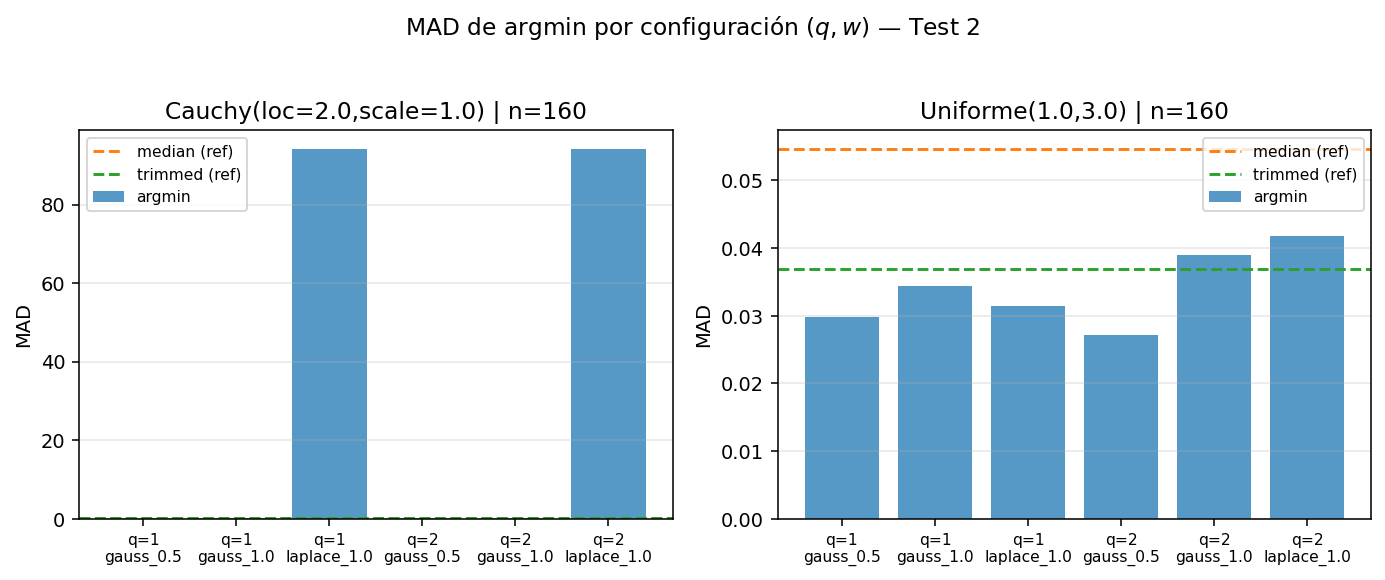

In [22]:
def plot_sn_argmin_compare(sn_summary: pd.DataFrame, sn_summary_pooled: pd.DataFrame,
                            metric: str, n_target: int | None, out_path: Path):
    dists = sorted(sn_summary['dist'].unique())
    if n_target is None:
        n_target = int(sn_summary['n'].max())
    fig, axes = plt.subplots(1, len(dists), figsize=(5*len(dists), 4), sharey=False)
    if len(dists) == 1:
        axes = [axes]
    for ax, dist in zip(axes, dists):
        sub = sn_summary[(sn_summary['dist']==dist) & (sn_summary['n']==n_target) & (sn_summary['estimator']=='argmin')]
        sub = sub.copy()
        sub['label'] = 'q=' + sub['q'].astype(str) + '\n' + sub['weight']
        sub = sub.sort_values(['q', 'weight'])
        ax.bar(sub['label'], sub[metric], color=ESTIMATOR_COLOR['argmin'], alpha=0.75, label='argmin')
        # Referencias
        ref = sn_summary_pooled[(sn_summary_pooled['dist']==dist) & (sn_summary_pooled['n']==n_target)]
        for _, r in ref.iterrows():
            ax.axhline(r[metric], color=ESTIMATOR_COLOR[r['estimator']], ls='--', lw=1.5,
                       label=f'{r["estimator"]} (ref)')
        ax.set_title(f'{dist} | n={n_target}')
        ax.set_ylabel(metric.upper())
        ax.grid(True, axis='y', alpha=0.3)
        ax.legend(fontsize=8)
        ax.tick_params(axis='x', rotation=0, labelsize=8)
    fig.suptitle(f'{metric.upper()} de argmin por configuración $(q, w)$ — Test 2', y=1.02)
    fig.tight_layout()
    fig.savefig(out_path, dpi=140, bbox_inches='tight')
    plt.close(fig)
    return out_path

if sn_h0 is not None:
    p = plot_sn_argmin_compare(sn_summary, sn_summary_pooled, 'rmse', None, FIG_DIR / 'aux_sn_argmin_rmse_by_config.png')
    display(Image(filename=str(p)))
    p = plot_sn_argmin_compare(sn_summary, sn_summary_pooled, 'mad', None, FIG_DIR / 'aux_sn_argmin_mad_by_config.png')
    display(Image(filename=str(p)))

## Test 2 — Boxplots del error

Boxplot del error $\hat\theta - \theta$ para una configuración de referencia ($q=2$, peso gaussiano de escala 1). Se recortan whiskers a percentiles [1, 99] (Cauchy).

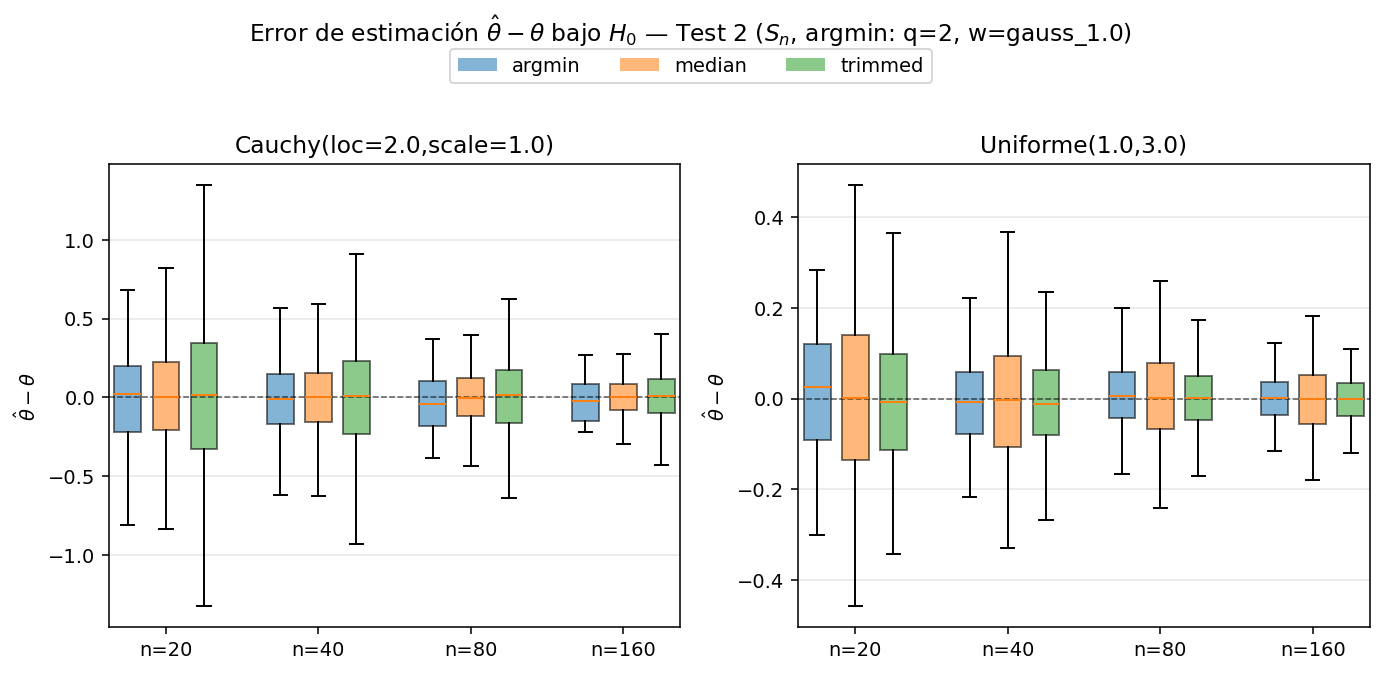

In [23]:
if sn_h0 is not None:
    q_ref, w_ref = 2, 'gauss_1.0'
    sub = sn_h0[(sn_h0['q']==q_ref) & (sn_h0['weight']==w_ref) | (sn_h0['estimator']!='argmin')].copy()
    # Para median/trimmed agregamos todas las (q, w) — son réplicas independientes
    p = boxplot_error_by_estimator(
        sub, f'Test 2 ($S_n$, argmin: q={q_ref}, w={w_ref})',
        FIG_DIR / 'aux_sn_error_boxplot.png', clip_percentile=(1, 99)
    )
    display(Image(filename=str(p)))

---

Las figuras guardadas en `results/figures/` son:

- `aux_tn_error_boxplot.png` — boxplot del error para Test 1
- `aux_tn_rmse_vs_n.png`, `aux_tn_mad_vs_n.png` — RMSE y MAD vs $n$
- `aux_tn_bias_vs_n.png` — sesgo MC con bandas ±1 SE
- `aux_sn_rmse_grid.png`, `aux_sn_mad_grid.png` — grid de RMSE/MAD por (dist, q, weight)
- `aux_sn_argmin_rmse_by_config.png`, `aux_sn_argmin_mad_by_config.png` — comparación de configuraciones $(q,w)$ para `argmin`
- `aux_sn_error_boxplot.png` — boxplot del error para Test 2 (config de referencia)